# Hierarchical clustering

#### Two types IS THERE:
#### 1. Agglomarative Hierarchical clustering.
#### 2. Divisive Hierarchical clustering.

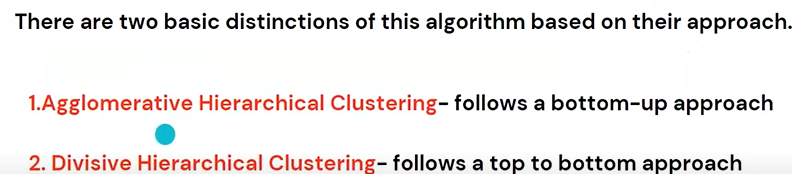

In [9]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232654.png")

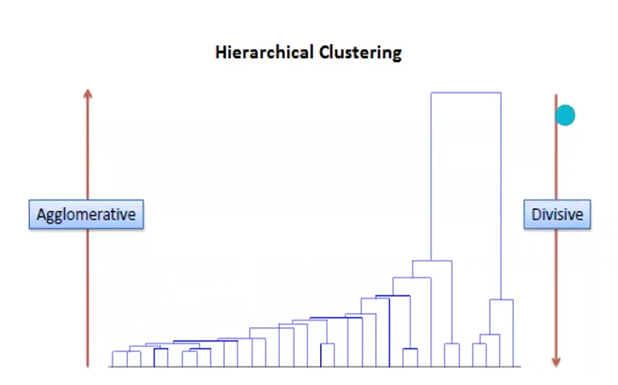

In [26]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232710.png")

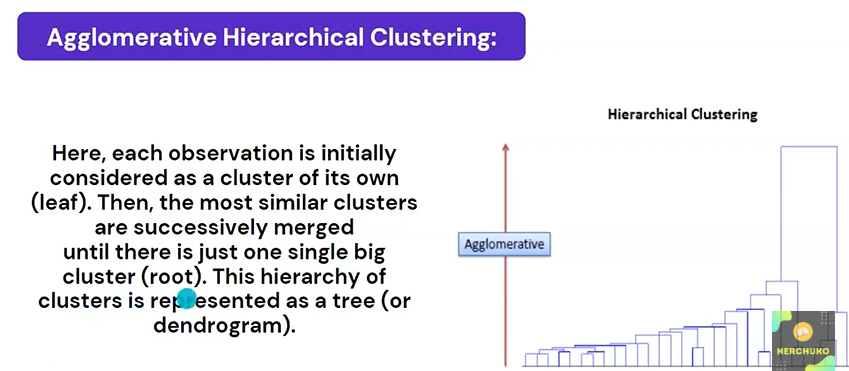

In [28]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232729.png")

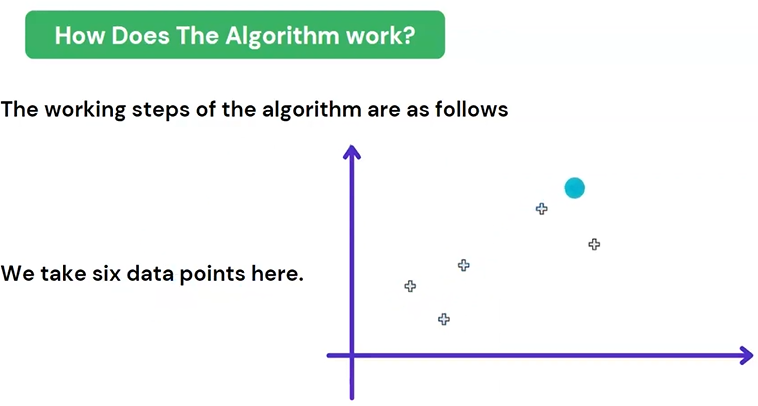

In [30]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232749.png")

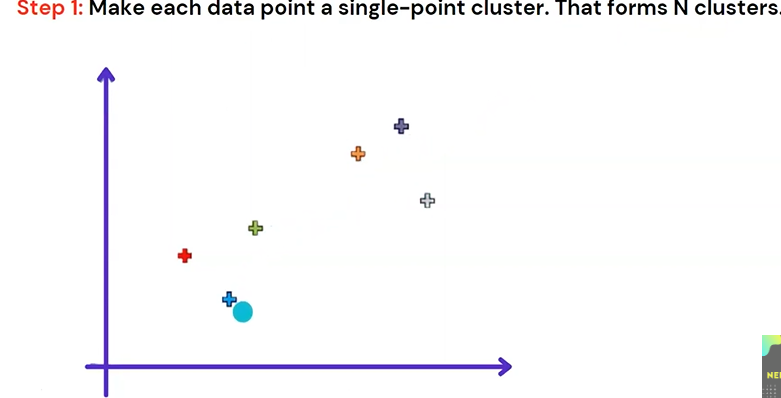

In [32]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232814.png")

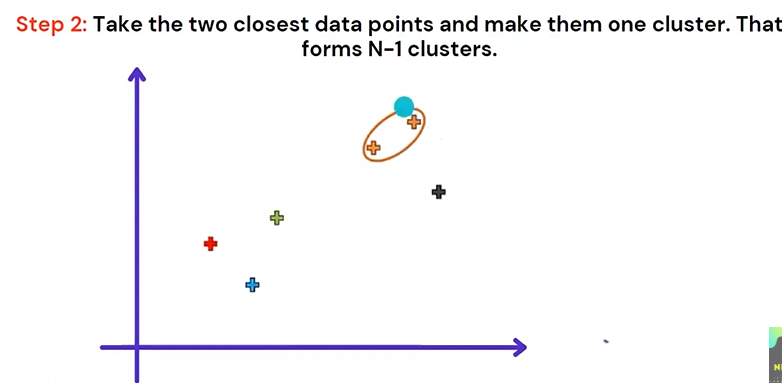

In [34]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232833.png")

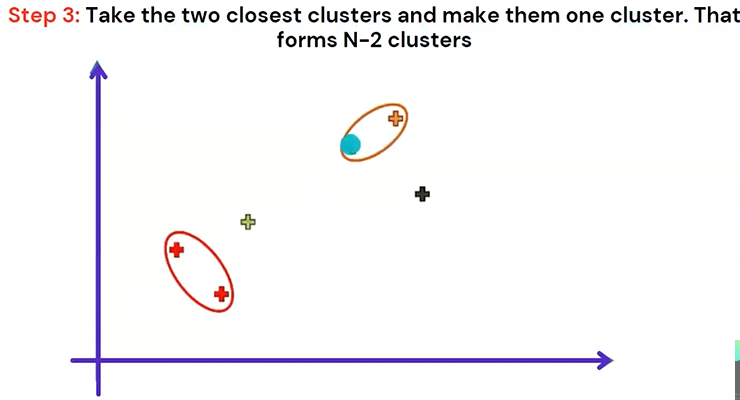

In [36]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232848.png")

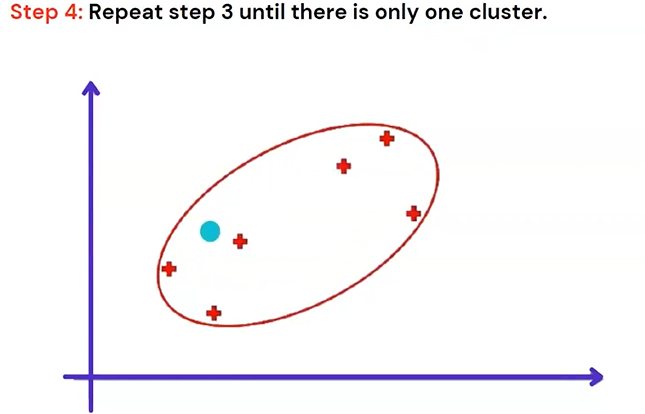

In [38]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232900.png")

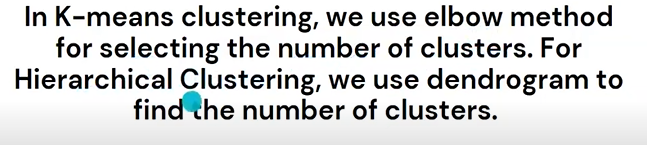

In [40]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232920.png")

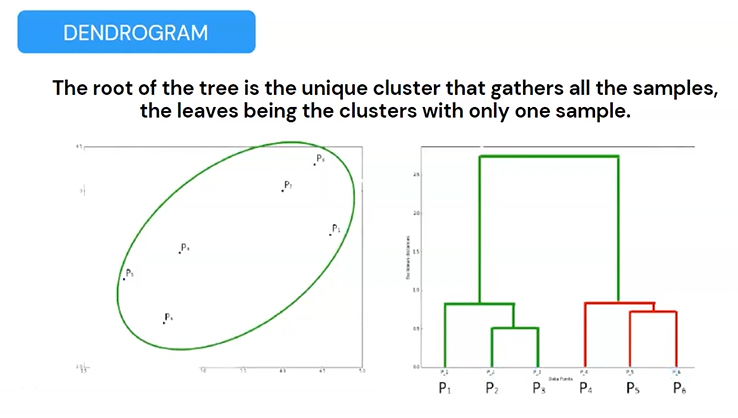

In [42]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232936.png")

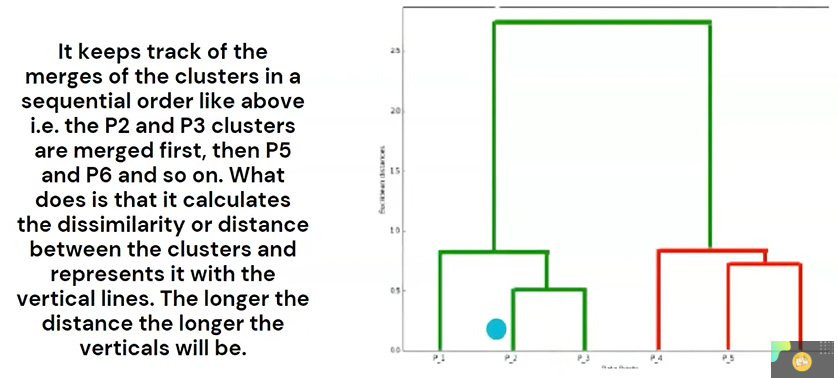

In [44]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 232952.png")

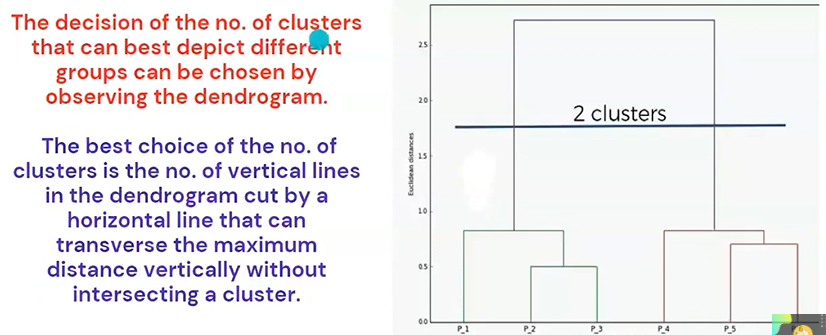

In [46]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-03-14 233017.png")

## we can use the following methods to determine the best number of clusters:
## we can use both of them

#### 1. Dendrogram Analysis
A dendrogram is a tree-like diagram that shows the splitting process in hierarchical clustering. To determine the optimal number of clusters:

Plot a dendrogram and look for a large vertical gap (longest branch) without splits.
Cut the tree at that level to determine the number of clusters.
📌 How to use it?

Run divisive clustering and plot the dendrogram.
Identify the largest gap between splits and select that level as the cut-off.


#### 2. Elbow Method (Inertia)
This method is commonly used in K-means, but it can be applied to hierarchical clustering by computing the within-cluster variance.

📌 Steps:

Perform divisive clustering for different values of clusters (K).
Compute total within-cluster sum of squared distances (WCSS).
Plot WCSS vs. number of clusters (K).
Identify the "elbow point" where the rate of decrease slows down.
✅ Optimal K is at the elbow point, where adding more clusters does not significantly reduce WCSS.


#### 3. Silhouette Score
The Silhouette Score measures how well-separated clusters are. It ranges from -1 to 1, where:

1 → Well-clustered.
0 → Overlapping clusters.
-1 → Incorrect clustering.
📌 Steps:

Run divisive clustering with different K values.
Compute Silhouette Score for each value of K.
Choose the K with the highest Silhouette Score.


#### 4. Davies-Bouldin Index (DBI)
This metric evaluates clustering quality based on intra-cluster similarity and inter-cluster separation.

📌 Steps:

Compute Davies-Bouldin Index for different values of K.
Lower DBI indicates better clustering.
Choose the K with the lowest DBI.


#### 5. Gap Statistic Method
This method compares the within-cluster dispersion of your data against randomly generated data.

📌 Steps:

Compute the clustering cost for different K values.
Compare it with a reference dataset (random distribution).
Select the largest gap between real and random clustering.


# Implementation


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [51]:
df=pd.read_csv(r"C:\Users\Windows\ML_Theory\Mall_Customers.csv")

In [53]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [55]:
df.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [80]:
X=df.iloc[:, 3: ].values


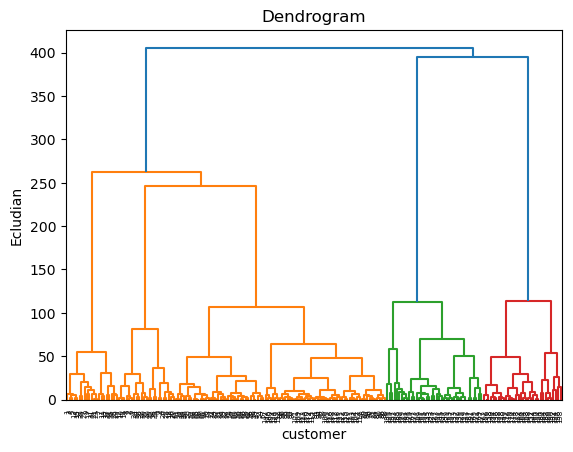

In [82]:
import scipy.cluster.hierarchy as hc
dendrogram =hc.dendrogram(hc.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('customer')
plt.ylabel('Ecludian')
plt.show()

In [92]:

from sklearn.cluster import AgglomerativeClustering
Ag=AgglomerativeClustering(n_clusters=5, linkage='average', metric='manhattan' )
y_Ag=Ag.fit_predict(X)

In [94]:
y_Ag

array([1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4,
       1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=int64)

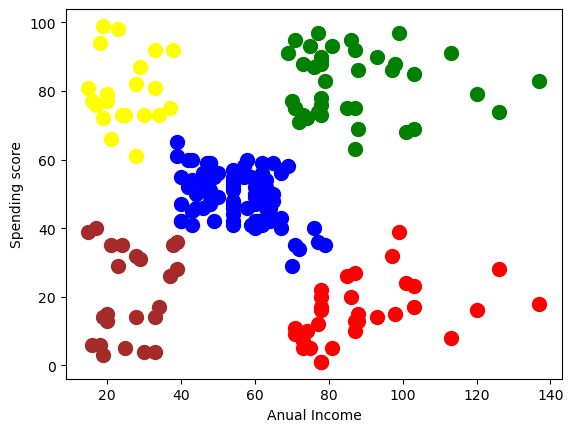

In [88]:
plt.scatter(X[y_Ag==0, 0], X[y_Ag==0,1], s=100, c='red', label='cluster1')
plt.scatter(X[y_Ag==1, 0], X[y_Ag==1,1], s=100, c='blue', label='cluster1')
plt.scatter(X[y_Ag==2, 0], X[y_Ag==2,1], s=100, c='green', label='cluster1')
plt.scatter(X[y_Ag==3, 0], X[y_Ag==3,1], s=100, c='yellow', label='cluster1')
plt.scatter(X[y_Ag==4, 0], X[y_Ag==4,1], s=100, c='brown', label='cluster1')
plt.xlabel('Anual Income')
plt.ylabel('Spending score')
plt.show()

# Divisive Hierarchiacal Clustering  (DIANA)

New point [[0 5]] belongs to cluster 4


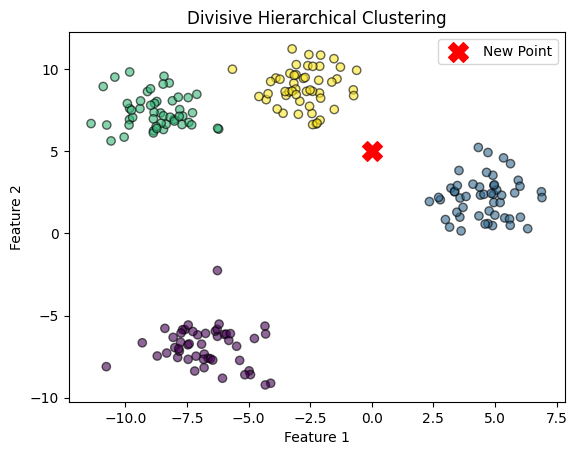

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

# Generate synthetic dataset
X, _ = make_blobs(n_samples=200, centers=4, random_state=42, cluster_std=1.2)

# Perform Divisive Clustering (DIANA) using hierarchical linkage
linked = linkage(X, method='ward')  # Ward minimizes variance, best for clustering

# Define the number of clusters
optimal_k = 4  # Change this value based on your dataset

# Assign cluster labels using fcluster
cluster_labels = fcluster(linked, optimal_k, criterion='maxclust')

# Function to predict cluster for new data points
def predict_cluster(new_data, X, cluster_labels):
    distances = squareform(pdist(np.vstack([X, new_data])))  # Compute pairwise distances
    nearest_cluster = cluster_labels[np.argmin(distances[-1, :-1])]  # Assign based on nearest point
    return nearest_cluster

# Example: Predict a new point's cluster
new_point = np.array([[0, 5]])  # Change this for new predictions
predicted_cluster = predict_cluster(new_point, X, cluster_labels)

print(f"New point {new_point} belongs to cluster {predicted_cluster}")

# Plot the clustered data
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='k', alpha=0.6)
plt.scatter(new_point[:, 0], new_point[:, 1], c='red', marker='X', s=200, label='New Point')
plt.title("Divisive Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


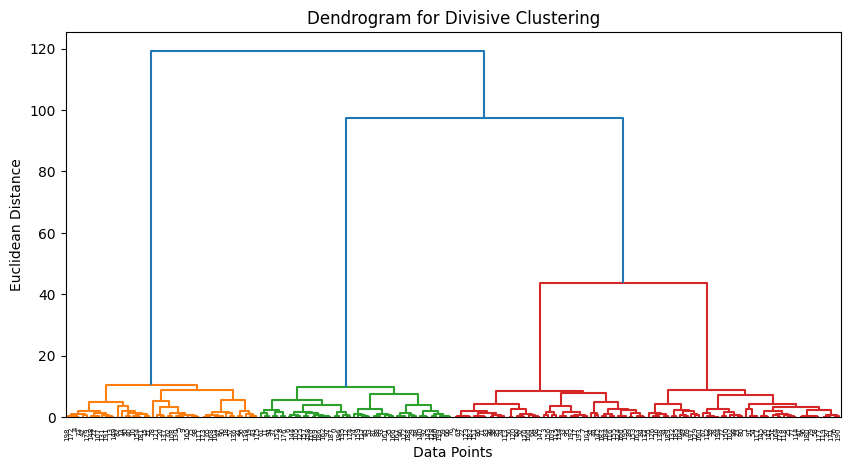

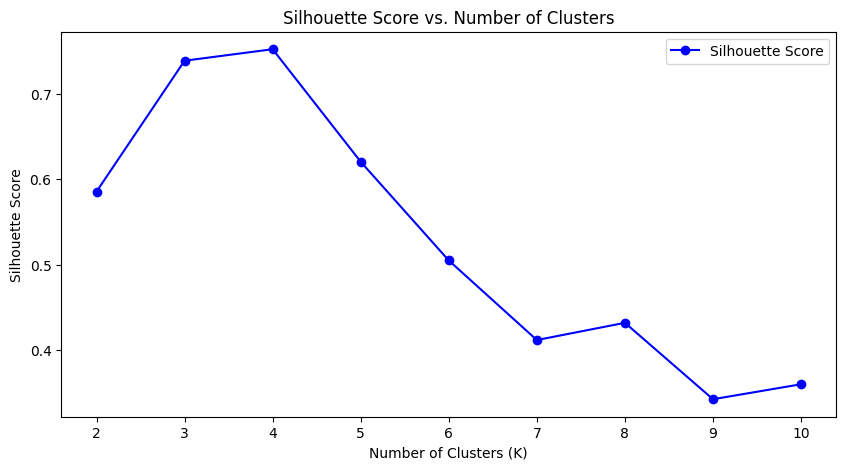

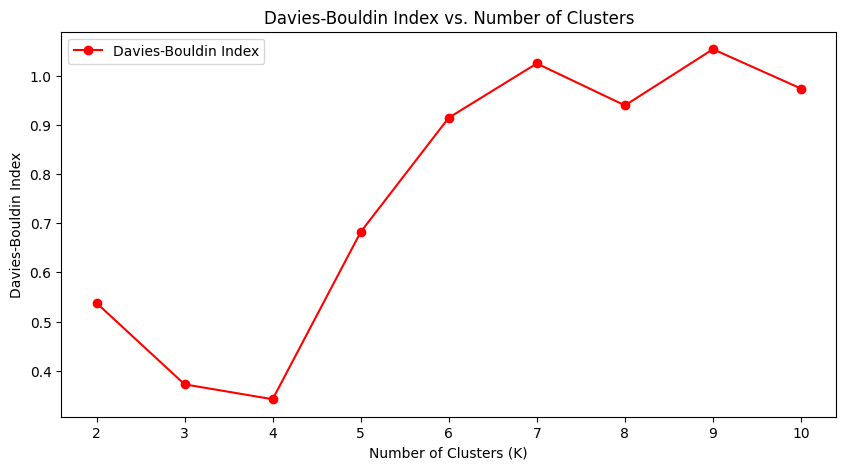

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

# Generate synthetic dataset
X, _ = make_blobs(n_samples=200, centers=4, random_state=42, cluster_std=1.2)

# Perform Divisive Hierarchical Clustering (DIANA)
linked = sch.linkage(X, method='ward')  # 'ward' minimizes variance, best for clustering

# Plot the Dendrogram
plt.figure(figsize=(10, 5))
sch.dendrogram(linked)
plt.title("Dendrogram for Divisive Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Function to evaluate clustering with different K values
def evaluate_clusters(X, max_k=10):
    silhouette_scores = []
    davies_bouldin_scores = []
    
    for k in range(2, max_k + 1):  # Start from 2 clusters
        clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = clustering.fit_predict(X)
        
        # Calculate Silhouette Score
        silhouette = silhouette_score(X, labels)
        silhouette_scores.append(silhouette)
        
        # Calculate Davies-Bouldin Index
        dbi = davies_bouldin_score(X, labels)
        davies_bouldin_scores.append(dbi)
    
    # Plot Silhouette Scores
    plt.figure(figsize=(10, 5))
    plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', linestyle='-', color='b', label="Silhouette Score")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Score vs. Number of Clusters")
    plt.legend()
    plt.show()
    
    # Plot Davies-Bouldin Scores
    plt.figure(figsize=(10, 5))
    plt.plot(range(2, max_k + 1), davies_bouldin_scores, marker='o', linestyle='-', color='r', label="Davies-Bouldin Index")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Davies-Bouldin Index")
    plt.title("Davies-Bouldin Index vs. Number of Clusters")
    plt.legend()
    plt.show()
    
# Run evaluation
evaluate_clusters(X, max_k=10)
